<h1>Basic Recurrent Neural Network (RNN) From Scratch</h1>
<h4>Source: <a href="https://www.coursera.org/learn/nlp-sequence-models?" target="_blank">Deep Learning AI. Sequence Models</a></h4>


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import image

<h2>Forward Propagation</h2>

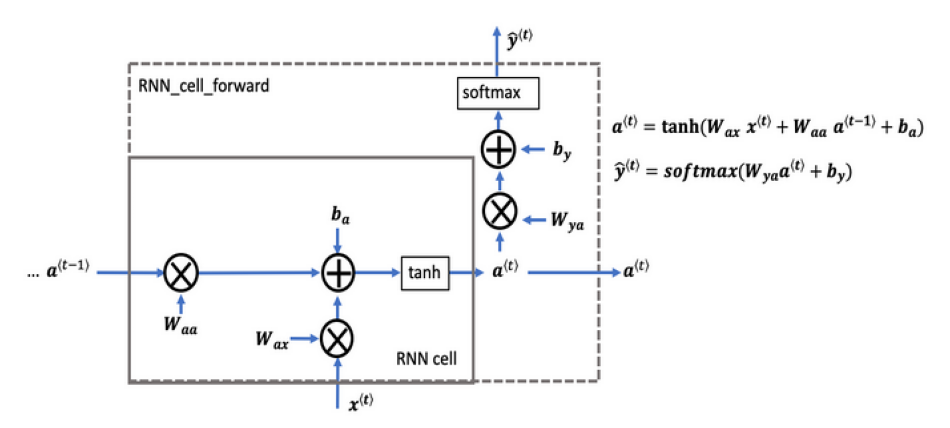

In [5]:
plt.figure(figsize=(12, 8))
im_path = "rnn.png"
img = image.imread(im_path)
plt.imshow(img)
plt.axis("off")
plt.show()

In [6]:
def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

In [7]:
def rnn_cell_forward(xt, a_prev, parameters):
    """
    Implements a single forward step of the RNN-cell as described in Figure above.

    Arguments:
    xt -- your input data at timestep "t", numpy array of shape (n_x, m).
    a_prev -- Hidden state at timestep "t-1", numpy array of shape (n_a, m)
    parameters -- python dictionary containing:
                        Wax -- Weight matrix multiplying the input, numpy array of shape (n_a, n_x)
                        Waa -- Weight matrix multiplying the hidden state, numpy array of shape (n_a, n_a)
                        Wya -- Weight matrix relating the hidden-state to the output, numpy array of shape (n_y, n_a)
                        ba --  Bias, numpy array of shape (n_a, 1)
                        by -- Bias relating the hidden-state to the output, numpy array of shape (n_y, 1)
    Returns:
    a_next -- next hidden state, of shape (n_a, m)
    yt_pred -- prediction at timestep "t", numpy array of shape (n_y, m)
    cache -- tuple of values needed for the backward pass, contains (a_next, a_prev, xt, parameters)
    """
    Wax = parameters["Wax"]
    Waa = parameters["Waa"]
    Wya = parameters["Wya"]
    ba = parameters["ba"]
    by = parameters["by"]
    
    a_next = tanh(np.dot(Wax, xt) + np.dot(Waa, a_prev) + ba)
    yt_pred = softmax(np.dot(Wya, a_next) + by)
    
    cache = (a_next, a_prev, xt, parameters)
    
    return a_next, yt_pred, cache

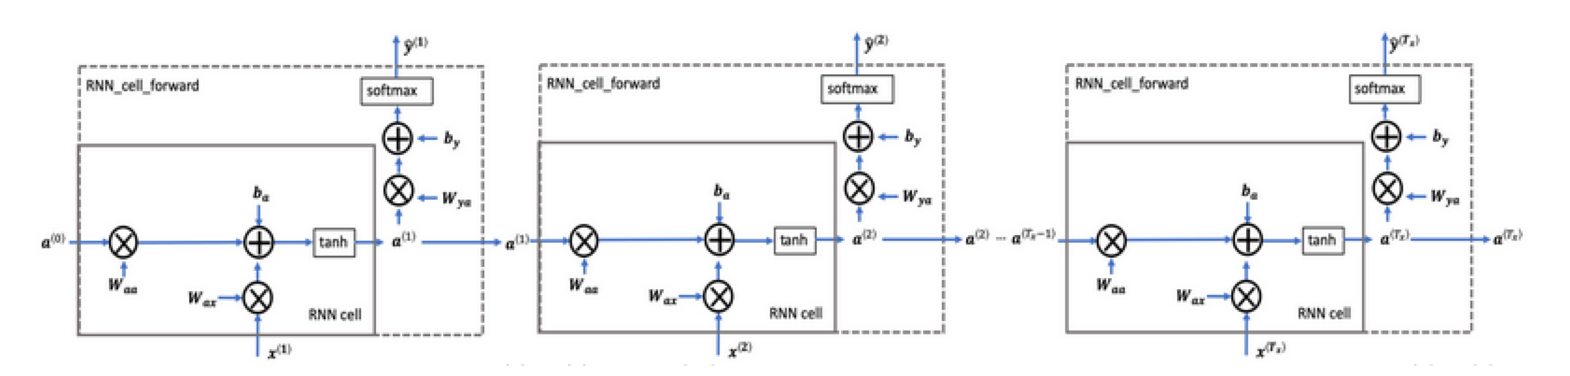

In [10]:
plt.figure(figsize=(20, 12))
im_path = "rnn2.png"
img = image.imread(im_path)
plt.imshow(img)
plt.axis("off")
plt.show()

In [11]:
def rnn_forward(x, a0, parameters):
    """
    Implement the forward propagation of the recurrent neural network described in Figure above.

    Arguments:
    x -- Input data for every time-step, of shape (n_x, m, T_x).
    a0 -- Initial hidden state, of shape (n_a, m)
    parameters -- python dictionary containing:
                        Waa -- Weight matrix multiplying the hidden state, numpy array of shape (n_a, n_a)
                        Wax -- Weight matrix multiplying the input, numpy array of shape (n_a, n_x)
                        Wya -- Weight matrix relating the hidden-state to the output, numpy array of shape (n_y, n_a)
                        ba --  Bias numpy array of shape (n_a, 1)
                        by -- Bias relating the hidden-state to the output, numpy array of shape (n_y, 1)

    Returns:
    a -- Hidden states for every time-step, numpy array of shape (n_a, m, T_x)
    y_pred -- Predictions for every time-step, numpy array of shape (n_y, m, T_x)
    caches -- tuple of values needed for the backward pass, contains (list of caches, x)
    """
    caches = []
    
    n_x, m, T_x = x.shape
    n_y, n_a = parameters["Wya"].shape
    
    a = np.zeros((n_a, m, T_x), dtype=float)
    y_pred = np.zeros((n_y, m, T_x), dtype=float)
    
    a_next = a0
    
    for t in range(T_x):
    
        a_next, yt_pred, cache = rnn_cell_forward(xt=x[:, :, t], a_prev=a_next, parameters=parameters)
        a[:,:,t] = a_next
        y_pred[:,:,t] = yt_pred
        caches.append(cache)
    
    caches = (caches, x)
    
    return a, y_pred, caches

<h2>Backward Propagation</h2>

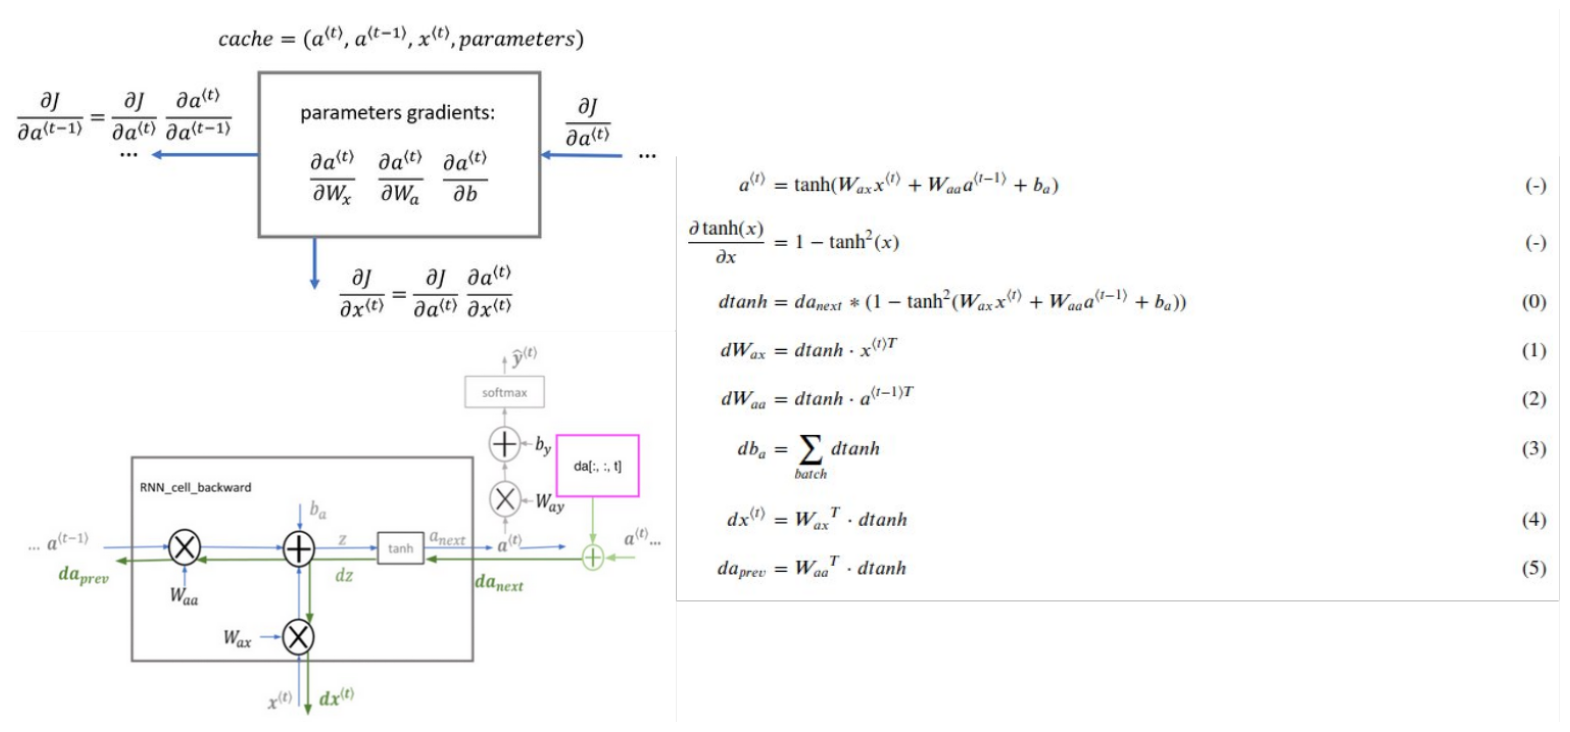

In [12]:
plt.figure(figsize=(20, 12))
im_path = "rnn3.png"
img = image.imread(im_path)
plt.imshow(img)
plt.axis("off")
plt.show()

In [13]:
def rnn_cell_backward(da_next, cache):
    """
    Implements the backward pass for the RNN-cell (single time-step).

    Arguments:
    da_next -- Gradient of loss with respect to next hidden state
    cache -- python dictionary containing useful values (output of rnn_cell_forward())

    Returns:
    gradients -- python dictionary containing:
                        dx -- Gradients of input data, of shape (n_x, m)
                        da_prev -- Gradients of previous hidden state, of shape (n_a, m)
                        dWax -- Gradients of input-to-hidden weights, of shape (n_a, n_x)
                        dWaa -- Gradients of hidden-to-hidden weights, of shape (n_a, n_a)
                        dba -- Gradients of bias vector, of shape (n_a, 1)
    """
    (a_next, a_prev, xt, parameters) = cache
    
    Wax = parameters["Wax"]
    Waa = parameters["Waa"]
    Wya = parameters["Wya"]
    ba = parameters["ba"]
    by = parameters["by"]
    
    dtanh = da_next * (1 - np.power(a_next, 2))
    dxt = np.dot(Wax.T, dtanh)
    dWax = np.dot(dtanh, xt.T)
    da_prev = np.dot(Waa.T, dtanh)
    dWaa = np.dot(dtanh, a_prev.T)
    dba = np.sum(dtanh, axis=1, keepdims=True)
    gradients = {"dxt": dxt, "da_prev": da_prev, "dWax": dWax, "dWaa": dWaa, "dba": dba}
    
    return gradients

In [14]:
def rnn_backward(da, caches):
    """
    Implement the backward pass for a RNN over an entire sequence of input data.

    Arguments:
    da -- Upstream gradients of all hidden states, of shape (n_a, m, T_x)
    caches -- tuple containing information from the forward pass (rnn_forward)
    
    Returns:
    gradients -- python dictionary containing:
                        dx -- Gradient w.r.t. the input data, numpy-array of shape (n_x, m, T_x)
                        da0 -- Gradient w.r.t the initial hidden state, numpy-array of shape (n_a, m)
                        dWax -- Gradient w.r.t the input's weight matrix, numpy-array of shape (n_a, n_x)
                        dWaa -- Gradient w.r.t the hidden state's weight matrix, numpy-array of shape (n_a, n_a)
                        dba -- Gradient w.r.t the bias, of shape (n_a, 1)
    """
    (caches, x) = caches
    (a1, a0, x1, parameters) = caches[0]
    
    n_a, m, T_x = da.shape
    n_x, m = x1.shape

    dx = np.zeros((n_x, m, T_x))
    dWax = np.zeros((n_a, n_x))
    dWaa = np.zeros((n_a, n_a))
    dba = np.zeros((n_a, 1))
    da0 = np.zeros((n_a, m))
    
    da_prev = np.zeros((n_a, m))
    
    for t in reversed(range(T_x)):

        gradients = rnn_cell_backward(da_next=da[:, :, t], cache=caches[t])
        dxt, da_prev, dWaxt, dWaat, dbat = gradients["dxt"], gradients["da_prev"], gradients["dWax"], gradients["dWaa"], gradients["dba"]
        
        dx[:, :, t] = dxt
        dWax += dWaxt
        dWaa += dWaat
        dba += dbat
    
    da0 = da_prev
    gradients = {"dx": dx, "da0": da0, "dWax": dWax, "dWaa": dWaa, "dba": dba}
    
    return gradients